<a href="https://colab.research.google.com/github/LindaPark-Young/fashion_mnist_nn.ipynb/blob/main/6_1_fashion_mnist_nn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fashion MNIST

Fashion Mnist는 옷, 바지 등 10가지 종류의 의류로 구성된 데이터입니다. 이 데이터는 (28, 28) 크기로 구성되어 있으며 Training Set 6만장, Test Set 1만장으로 총합 7만장으로 이루어져 있습니다. Keras에서 dataset을 import 할 수 있고, 처음 import 시 다운로드 하는 과정이 추가됩니다.

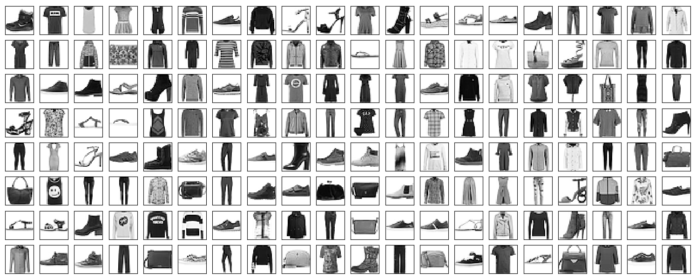


## 데이터 로드

In [ ]:
import tensorflow as tf

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


### 데이터 shape 확인

In [ ]:
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


### 이미지 출력
#### 5 x 5로 이미지 출력
#### cmap='gray_r'  

In [ ]:
import matplotlib.pyplot as plt

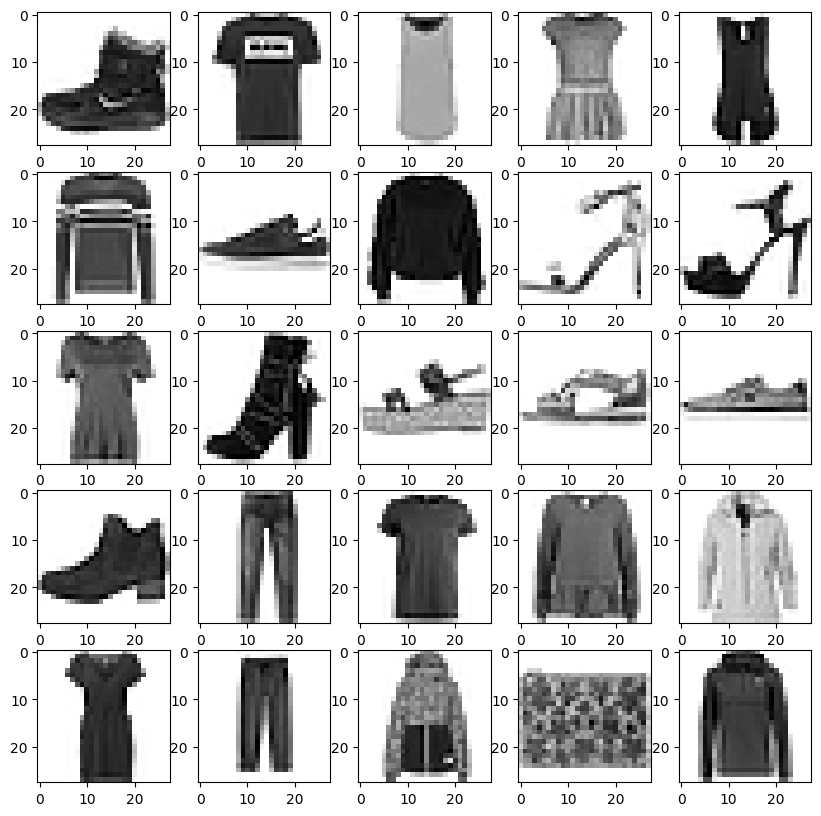

In [ ]:
fig, axs = plt.subplots(5,5, figsize=(10, 10))
for i in range(5):
  for j in range(5):
    axs[i, j].imshow(x_train[i*5+j], cmap='gray_r')
plt.show()


## class 확인

In [ ]:
items = {0:'T-shirt/top', 1:'Trouser', 2:'Pullover', 3:'Dress',
         4:'Coat', 5:'Sandal', 6:'Shirt', 7:'Sneaker',
         8:'Bag', 9:'Ankel boot'}

In [ ]:
y_train[0:25]

array([9, 0, 0, 3, 0, 2, 7, 2, 5, 5, 0, 9, 5, 5, 7, 9, 1, 0, 6, 4, 3, 1,
       4, 8, 4], dtype=uint8)

In [ ]:
print([items[i] for i in y_train[:25]])

['Ankel boot', 'T-shirt/top', 'T-shirt/top', 'Dress', 'T-shirt/top', 'Pullover', 'Sneaker', 'Pullover', 'Sandal', 'Sandal', 'T-shirt/top', 'Ankel boot', 'Sandal', 'Sandal', 'Sneaker', 'Ankel boot', 'Trouser', 'T-shirt/top', 'Shirt', 'Coat', 'Dress', 'Trouser', 'Coat', 'Bag', 'Coat']


In [ ]:
import numpy as np

In [ ]:
np.unique(y_train, return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000]))

In [ ]:
np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [ ]:
print([items[i] for i in np.unique(y_train)])

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankel boot']


## 검증데이터(validation data) 생성

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

In [ ]:
print(x_train.shape, y_train.shape)
print(x_val.shape, y_val.shape)
print(x_test.shape, y_test.shape)

(48000, 28, 28) (48000,)
(12000, 28, 28) (12000,)
(10000, 28, 28) (10000,)


## one-hot encoding

In [ ]:
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_val = tf.keras.utils.to_categorical(y_val, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)


In [ ]:
print(y_train.shape, y_val.shape, y_test.shape)

(48000, 10) (12000, 10) (10000, 10)


## 정규화(Normalization)

In [ ]:
x_train = x_train / 255
x_val = x_val / 255
x_test = x_test / 255

In [ ]:
print(x_val[0:10])

[[[0.         0.         0.         ... 0.         0.         0.        ]
  [0.         0.         0.         ... 0.         0.         0.        ]
  [0.         0.         0.         ... 0.         0.         0.        ]
  ...
  [0.00784314 0.         0.43921569 ... 0.         0.         0.00392157]
  [0.00784314 0.         0.08235294 ... 0.         0.00392157 0.        ]
  [0.         0.         0.         ... 0.         0.         0.        ]]

 [[0.         0.         0.         ... 0.         0.         0.        ]
  [0.         0.         0.         ... 0.         0.         0.        ]
  [0.         0.         0.         ... 0.         0.         0.        ]
  ...
  [0.         0.         0.         ... 0.         0.         0.        ]
  [0.         0.         0.         ... 0.         0.         0.        ]
  [0.         0.         0.         ... 0.         0.         0.        ]]

 [[0.         0.         0.         ... 0.         0.         0.        ]
  [0.         0.      

## 직렬화

In [ ]:
x_train = x_train.reshape(-1, 28 * 28)
x_val = x_val.reshape(-1, 28 * 28)
x_test = x_test.reshape(-1, 28 * 28)

In [ ]:
print(x_train.shape, x_val.shape, x_test.shape)

(48000, 784) (12000, 784) (10000, 784)


## model 생성

In [ ]:
from tensorflow.keras import layers, models

In [ ]:
784-128-64-32-10

In [ ]:
model = models.Sequential([
      layers.Dense(128, activation='sigmoid', input_shape=(784,)),
      layers.Dense(64, activation='relu'),
      layers.Dense(32, activation='relu'),
      layers.Dense(10, activation='softmax')

])


In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,146 (434.16 KB)

 Trainable params: 111,146 (434.16 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(loss='categorical_crossentropy', metrics=['accuracy'])

## 학습

In [ ]:
history = model.fit(x_train, y_train, epochs=30, validation_data=(x_val, y_val))

Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9276 - loss: 0.2043 - val_accuracy: 0.8792 - val_loss: 0.4566
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9279 - loss: 0.2004 - val_accuracy: 0.8820 - val_loss: 0.4849
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9286 - loss: 0.1997 - val_accuracy: 0.8850 - val_loss: 0.5065
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9295 - loss: 0.1997 - val_accuracy: 0.8819 - val_loss: 0.5503
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9313 - loss: 0.1970 - val_accuracy: 0.8779 - val_loss: 0.6032
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9319 - loss: 0.1923 - val_accuracy: 0.8871 - val_loss: 0.5618
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9325 - loss: 0.1903 - val_accuracy: 0.8856 - val_loss: 0.5191
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9321 - loss: 0.1902 - 

## 학습곡선

In [ ]:
history.history

{'accuracy': [0.9276250004768372,
  0.9278958439826965,
  0.9286249876022339,
  0.92947918176651,
  0.9313125014305115,
  0.9319166541099548,
  0.9324791431427002,
  0.9321249723434448,
  0.9334583282470703,
  0.9338333606719971,
  0.9362291693687439,
  0.9359375238418579,
  0.9358541369438171,
  0.9376458525657654,
  0.9384999871253967,
  0.9375625252723694,
  0.9394375085830688,
  0.9382916688919067,
  0.9417916536331177,
  0.942145824432373,
  0.9416875243186951,
  0.9413750171661377,
  0.9439583420753479,
  0.9440208077430725,
  0.945354163646698,
  0.9447083473205566,
  0.945604145526886,
  0.9458333253860474,
  0.9448333382606506,
  0.9468333125114441],
 'loss': [0.20430710911750793,
  0.20036590099334717,
  0.1996924877166748,
  0.19971254467964172,
  0.19697315990924835,
  0.192286416888237,
  0.19030000269412994,
  0.19015181064605713,
  0.18660447001457214,
  0.18748889863491058,
  0.18571223318576813,
  0.17994339764118195,
  0.18026994168758392,
  0.17818176746368408,
  0.1

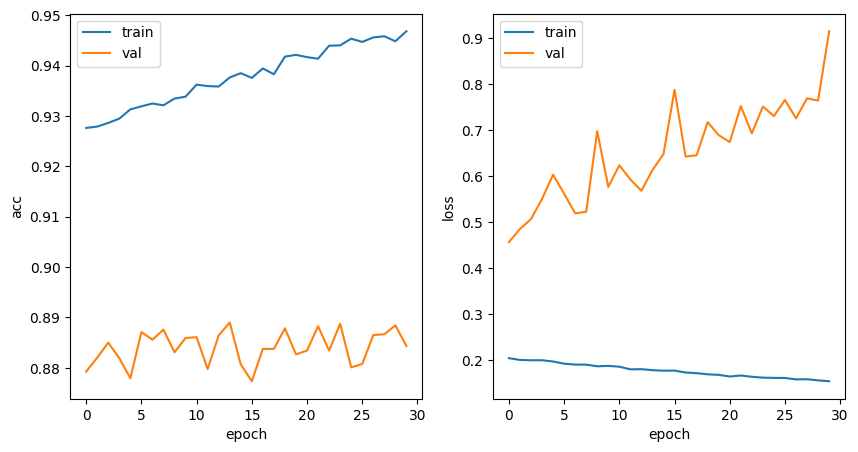

In [ ]:
plt.figure(figsize=(10, 5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['train', 'val'])
plt.xlabel('epoch')
plt.ylabel('acc')

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['train', 'val'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

## 과대적합(Over fitting)/과소적합(Under fitting)

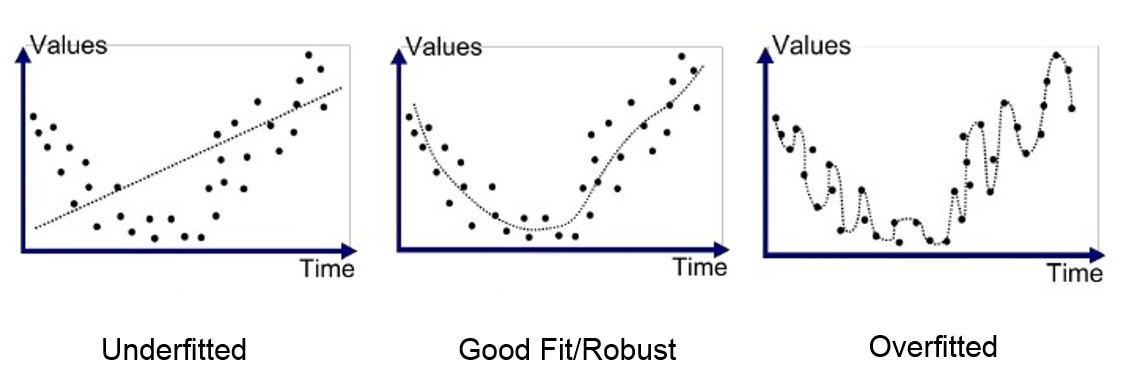

In [ ]:
model1 = models.Sequential([
      layers.Dense(128, activation='sigmoid', input_shape=(784,)),
      layers.Dropout(0.3),
      layers.Dense(64, activation='relu'),
      layers.Dense(32, activation='relu'),
      layers.Dense(10, activation='softmax')

])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model1.compile(loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
history1 = model1.fit(x_train, y_train, epochs=30, validation_data=(x_val,y_val))

Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7704 - loss: 0.6372 - val_accuracy: 0.8340 - val_loss: 0.4456
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8344 - loss: 0.4574 - val_accuracy: 0.8458 - val_loss: 0.4159
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8491 - loss: 0.4178 - val_accuracy: 0.8579 - val_loss: 0.3870
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8567 - loss: 0.3984 - val_accuracy: 0.8653 - val_loss: 0.3660
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8635 - loss: 0.3806 - val_accuracy: 0.8638 - val_loss: 0.3700
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8677 - loss: 0.3674 - val_accuracy: 0.8717 - val_loss: 0.3534
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8698 - loss: 0.3605 - val_accuracy: 0.8759 - val_loss: 0.3479
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8735 - loss: 0.3499 - 

In [ ]:
history1.history

{'accuracy': [0.770395815372467,
  0.8343541622161865,
  0.8491041660308838,
  0.8566874861717224,
  0.8634583353996277,
  0.8676875233650208,
  0.8698333501815796,
  0.8734583258628845,
  0.874833345413208,
  0.878333330154419,
  0.8792916536331177,
  0.879770815372467,
  0.8811666369438171,
  0.8806250095367432,
  0.8829166889190674,
  0.8843333125114441,
  0.8837500214576721,
  0.883062481880188,
  0.8841041922569275,
  0.8871250152587891,
  0.8866249918937683,
  0.8867499828338623,
  0.8877916932106018,
  0.8862291574478149,
  0.8881041407585144,
  0.8895000219345093,
  0.8890416622161865,
  0.8903124928474426,
  0.8896250128746033,
  0.890874981880188],
 'loss': [0.6372246146202087,
  0.45744308829307556,
  0.4178081452846527,
  0.3983597755432129,
  0.38063815236091614,
  0.36741697788238525,
  0.3605329692363739,
  0.34992992877960205,
  0.34874653816223145,
  0.34198763966560364,
  0.3401077687740326,
  0.33972686529159546,
  0.33610087633132935,
  0.3386281430721283,
  0.33480

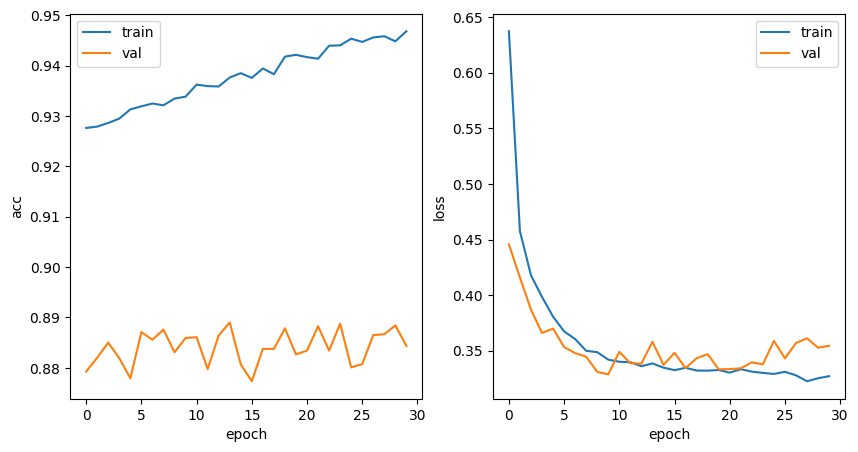

In [ ]:
plt.figure(figsize=(10, 5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['train', 'val'])
plt.xlabel('epoch')
plt.ylabel('acc')

plt.subplot(1,2,2)
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])
plt.legend(['train', 'val'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

In [ ]:
model1.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8744 - loss: 0.3826


[0.38259008526802063, 0.8744000196456909]

In [ ]:
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1000 - loss: 2.3660


[2.3659844398498535, 0.10000000149011612]

In [ ]:
model.save('fmnist_nn.h5')

In [ ]:
model3 = models.load_model('fmnist_nn.h5')

In [ ]:
model3.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,146 (434.16 KB)

 Trainable params: 111,146 (434.16 KB)

 Non-trainable params: 0 (0.00 B)